Propagazione MEO in corso per 30 giorni...

  MISSION ANALYSIS: MEO DOPO 30 GIORNI
  Modello: Gravità 10x10, SRP, Luni-Solar Third Body (NO DRAG)
1. SEMIASSE MAGGIORE (a)
   Iniziale: 29600.000 km
   Finale:   29597.950 km
   Delta:    -2049.92 metri (-2.049925 km) (Variazione periodica minore, no decadimento)
--------------------------------------------------------------------
2. ECCENTRICITÀ (e)
   Iniziale: 0.000100
   Finale:   0.000109
   Delta:    0.000009 (Oscillazioni per SRP e Third Body)
--------------------------------------------------------------------
3. INCLINAZIONE (i)
   Iniziale: 56.00000 deg
   Finale:   56.01240 deg
   Delta:    0.01240 deg
--------------------------------------------------------------------
4. RAAN (Ω)
   Iniziale: 0.000 deg
   Finale:   359.174 deg (Standard Modulo 360)
   Delta:    -0.826 deg (Regressione J2 lenta)

Generazione grafico 3D in corso...


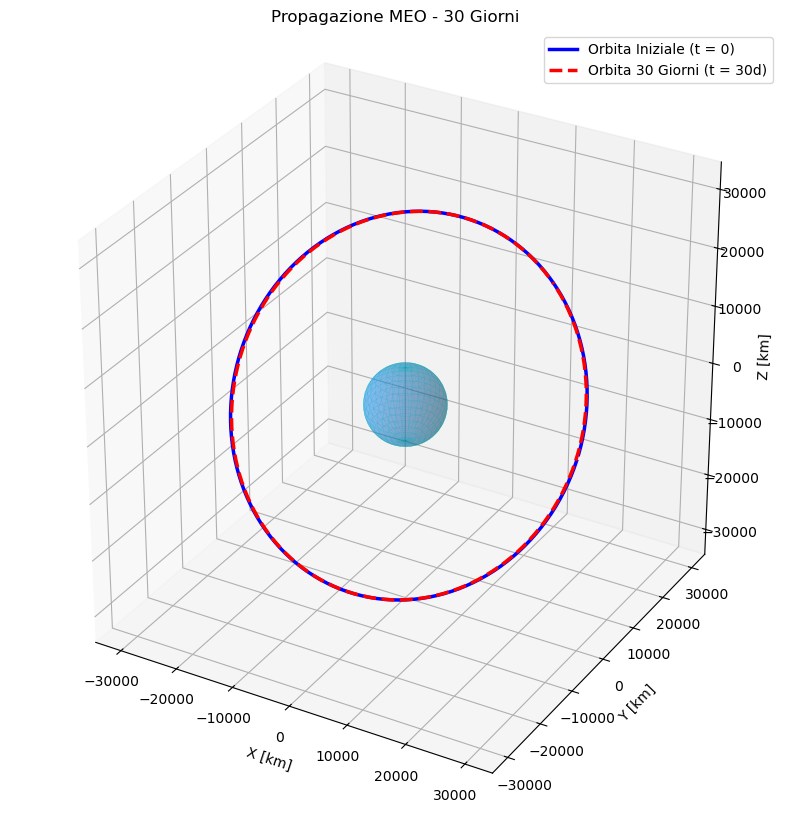

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# 1. INIZIALIZZAZIONE
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)
inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, Constants.WGS84_EARTH_FLATTENING, earth_frame)
mu = Constants.WGS84_EARTH_MU

# 3. CREAZIONE DELL'ORBITA (MEO - Stile Galileo)
a = 29600000.0  # Semiasse maggiore ~ 29600 km
e = 0.0001      # Orbita quasi circolare
i = math.radians(56.0) # Inclinazione tipica GNSS
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 700.0) # Massa 700 kg

# 4. CONFIGURAZIONE DEL PROPAGATORE
min_step = 0.001
max_step = 500.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
integrator = DormandPrince853Integrator(min_step, max_step, JArray_double.cast_(tolerances[0]), JArray_double.cast_(tolerances[1]))
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)
ephemeris_generator = propagator.getEphemerisGenerator()

# 5. AGGIUNTA PERTURBAZIONI (MEO: NO DRAG)
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(15.0, 1.2)))

# 6. PROPAGAZIONE (30 GIORNI)
giorni = 30.0
duration = giorni * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagazione MEO in corso per {int(giorni)} giorni...")
final_state = propagator.propagate(final_date)
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# 7. MISSION ANALYSIS REPORT
a_fin = orbit_30d.getA()
e_fin = orbit_30d.getE()
i_fin = math.degrees(orbit_30d.getI())
raan_fin_raw = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())
omega_fin_raw = math.degrees(orbit_30d.getPerigeeArgument())

raan_fin_mod = raan_fin_raw % 360.0
omega_fin_mod = omega_fin_raw % 360.0
delta_raan = (raan_fin_raw - math.degrees(raan) + 180.0) % 360.0 - 180.0
delta_omega = (omega_fin_raw - math.degrees(omega) + 180.0) % 360.0 - 180.0

print("\n====================================================================")
print(f"  MISSION ANALYSIS: MEO DOPO {int(giorni)} GIORNI")
print("  Modello: Gravità 10x10, SRP, Luni-Solar Third Body (NO DRAG)")
print("====================================================================")
print(f"1. SEMIASSE MAGGIORE (a)")
print(f"   Iniziale: {a/1000:.3f} km")
print(f"   Finale:   {a_fin/1000:.3f} km")
print(f"   Delta:    {(a_fin - a):.2f} metri ({(a_fin - a)/1000:.6f} km) (Variazione periodica minore, no decadimento)")
print("--------------------------------------------------------------------")
print(f"2. ECCENTRICITÀ (e)")
print(f"   Iniziale: {e:.6f}")
print(f"   Finale:   {e_fin:.6f}")
print(f"   Delta:    {e_fin - e:.6f} (Oscillazioni per SRP e Third Body)")
print("--------------------------------------------------------------------")
print(f"3. INCLINAZIONE (i)")
print(f"   Iniziale: {math.degrees(i):.5f} deg")
print(f"   Finale:   {i_fin:.5f} deg")
print(f"   Delta:    {i_fin - math.degrees(i):.5f} deg")
print("--------------------------------------------------------------------")
print(f"4. RAAN (Ω)")
print(f"   Iniziale: {math.degrees(raan):.3f} deg")
print(f"   Finale:   {raan_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"   Delta:    {delta_raan:.3f} deg (Regressione J2 lenta)")
print("====================================================================\n")
# ==========================================
# 8. VISUALIZZAZIONE 3D
# ==========================================
print("Generazione grafico 3D in corso...")
# Periodo orbitale approssimativo per una MEO a 29600 km (circa 14 ore)
periodo_orbitale = 50400.0  

def estrai_orbita(start_time, end_time):
    times = np.linspace(start_time, end_time, 150)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris_generator.getGeneratedEphemeris().propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = estrai_orbita(0, periodo_orbitale)                                  
x30, y30, z30 = estrai_orbita(duration - periodo_orbitale, duration)             

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Creazione della Terra in scala
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

# Plot delle orbite
ax.plot(x0, y0, z0, color='blue', linewidth=2.5, label='Orbita Iniziale (t = 0)')
ax.plot(x30, y30, z30, color='red', linewidth=2.5, linestyle='dashed', label='Orbita 30 Giorni (t = 30d)')

# Limiti del grafico adattati alla MEO
lim = a / 1000.0 + 5000 
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Propagazione MEO - 30 Giorni')
ax.legend(loc='upper right')

plt.show()